# Exploratory Data Analysis

Before jumping into RFM, churn, and cohorts, this notebook takes one more pass through the
cleaned data just to build intuition. Nothing here changes the data, it's purely look-and-learn:
how big are typical orders, how often do people actually come back, and does the seasonality
that showed up in the SQL queries hold up when I plot it directly.

Two tables get used below. `orders_clean_full.csv` (all cleaned orders, guests included) for
anything revenue or product related, and `orders_clean_customer_level.csv` (guests excluded)
for anything that needs to track an individual customer, since a guest order has no ID to track.

## Step 0: Load and set up plotting

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df_full = pd.read_csv('../datasets/cleaned/orders_clean_full.csv', dtype={'Customer ID': str}, parse_dates=['InvoiceDate'])
df_cust = pd.read_csv('../datasets/cleaned/orders_clean_customer_level.csv', dtype={'Customer ID': str}, parse_dates=['InvoiceDate'])

print("Full cleaned table:", df_full.shape)
print("Customer-level table:", df_cust.shape)
print("Date range:", df_full['InvoiceDate'].min(), "to", df_full['InvoiceDate'].max())


Full cleaned table: (1003386, 9)
Customer-level table: (776592, 9)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


## Step 1: Order value distribution

An "order" here means one invoice, so first I need to collapse the line-item table up to one
row per invoice by summing `LineTotal`. This is the same rollup a business person means when
they ask "what's a typical order worth.

count     39529.00
mean        497.00
std        1460.16
min           0.19
25%         150.26
50%         301.20
75%         484.25
max      168469.60
Name: order_value, dtype: float64


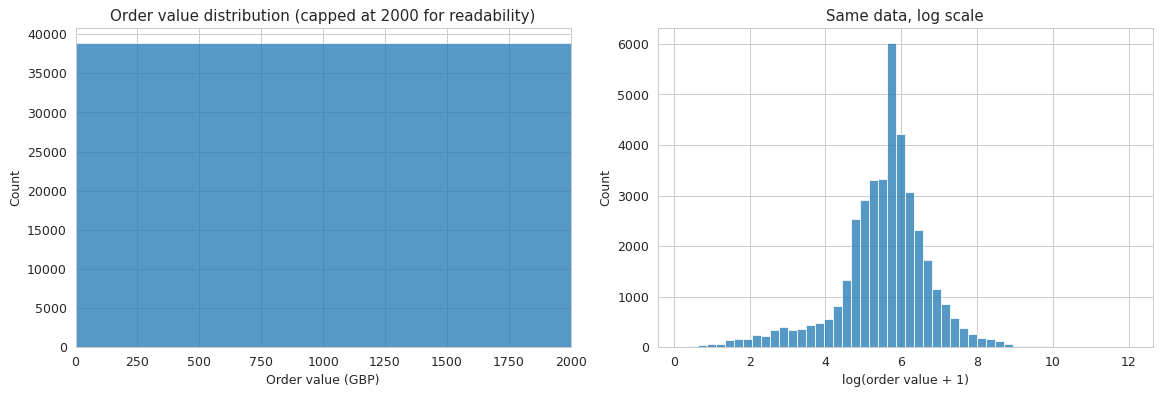

In [4]:
order_values = df_full.groupby('Invoice')['LineTotal'].sum().reset_index(name='order_value')
print(order_values['order_value'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(order_values['order_value'], bins=60, ax=axes[0])
axes[0].set_xlim(0, 2000)
axes[0].set_title('Order value distribution (capped at 2000 for readability)')
axes[0].set_xlabel('Order value (GBP)')

sns.histplot(np.log1p(order_values['order_value']), bins=50, ax=axes[1])
axes[1].set_title('Same data, log scale')
axes[1].set_xlabel('log(order value + 1)')
plt.tight_layout()
plt.show()

The median order sits around £300, but the mean is nearly £500 and the max is over £168,000,
so this is heavily right-skewed. That's expected for a business that mixes casual gift buyers
with wholesale accounts placing bulk orders. The log-scale version on the right makes it clear
this isn't a clean bell curve, there's a long tail of big orders pulling the average up. This
matters later: average order value on its own is a misleading KPI unless it's shown alongside
the median, or unless wholesale accounts get separated out.

I'm not removing these big orders as outliers. They're real, and one of them (customer 18102,
already flagged in the Phase 3 top-spenders query) is clearly a wholesale relationship worth
protecting, not noise to clean away.

## Step 2: Orders per customer

This is the raw shape behind the 72.4% repeat rate from the Phase 3 SQL query. Worth seeing the
actual distribution rather than just the one summary number.

count    5852.00
mean        6.26
std        12.75
min         1.00
25%         1.00
50%         3.00
75%         7.00
max       373.00
Name: num_orders, dtype: float64
One-time customers: 27.6%


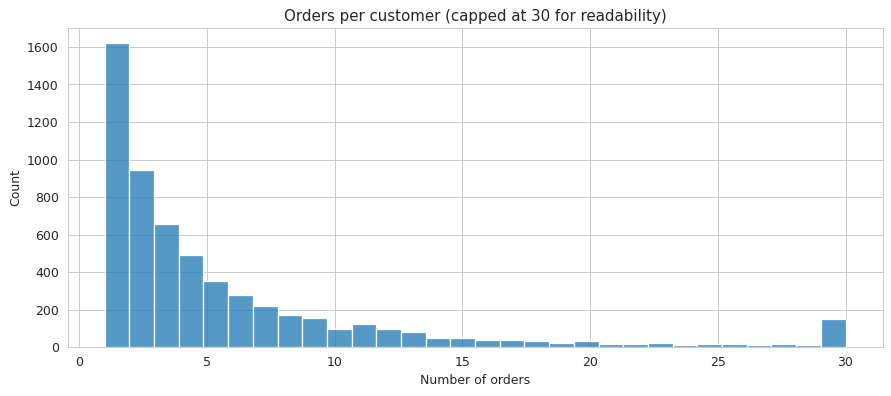

In [7]:
orders_per_customer = df_cust.groupby('Customer ID')['Invoice'].nunique().reset_index(name='num_orders')
print(orders_per_customer['num_orders'].describe().round(2))

fig, ax = plt.subplots(figsize=(10, 4.5))
capped = orders_per_customer['num_orders'].clip(upper=30)
sns.histplot(capped, bins=30, ax=ax)
ax.set_title('Orders per customer (capped at 30 for readability)')
ax.set_xlabel('Number of orders')
plt.tight_layout()
plt.show()

one_time_pct = (orders_per_customer['num_orders'] == 1).mean() * 100
print(f"One-time customers: {one_time_pct:.1f}%")

Matches Phase 3: a bit over a quarter of customers only ever place one order, and the median
customer has placed 3. The distribution has the same long tail as order value, a small group of
customers (373 orders for customer 14911, for example) are placing far more orders than anyone
else. Those customers deserve their own look later, since losing one of them costs a lot more
than losing a typical one-time buyer.

## Step 3: Seasonality, plotted directly

Phase 3's SQL query already showed the monthly revenue numbers in a table. Here's the same
thing as a line, which makes the seasonal pattern easier to actually see instead of just read.

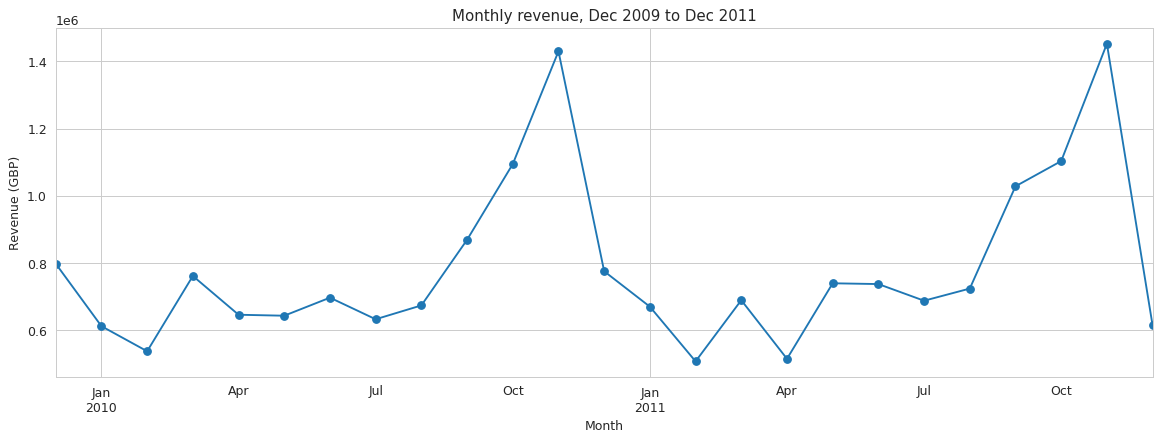

In [10]:
monthly_revenue = df_full.set_index('InvoiceDate').resample('MS')['LineTotal'].sum()

fig, ax = plt.subplots(figsize=(13, 5))
monthly_revenue.plot(ax=ax, marker='o')
ax.set_title('Monthly revenue, Dec 2009 to Dec 2011')
ax.set_ylabel('Revenue (GBP)')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()

Same pattern both years: a dip in January and February, a climb through the back half of the
year, and a peak in November right before the Christmas shipping cutoff. December itself looks
low both years but for different reasons: December 2009 is a partial month (the dataset starts
Dec 1), and December 2011 is a partial month too (the dataset ends Dec 9). Neither is a real
drop-off, and it's worth a note in the executive summary so nobody reads a December decline
into this that isn't actually there.

This confirms the business is genuinely seasonal, which is exactly why cohort retention needs
to be read carefully later: a cohort that started in November is going to look different from
one that started in February, just because of when in the calendar they landed, not because
those customers are more or less loyal.

## Step 4: Where the revenue comes from geographically

Quick look at country concentration, mostly to confirm this is a UK-centric business before
building anything that segments by country later.

In [13]:
country_revenue = df_full.groupby('Country')['LineTotal'].sum().sort_values(ascending=False)
country_customers = df_cust.groupby('Country')['Customer ID'].nunique().sort_values(ascending=False)

print("Top 10 countries by revenue:")
print(country_revenue.head(10).round(0))
print()
print("Top 10 countries by customer count:")
print(country_customers.head(10))

uk_share = country_revenue['United Kingdom'] / country_revenue.sum() * 100
print(f"\nUK share of total revenue: {uk_share:.1f}%")

Top 10 countries by revenue:
Country
United Kingdom    16803186.0
EIRE                623414.0
Netherlands         549773.0
Germany             383289.0
France              311090.0
Australia           167800.0
Spain                97767.0
Switzerland          94025.0
Sweden               86319.0
Denmark              67423.0
Name: LineTotal, dtype: float64

Top 10 countries by customer count:
Country
United Kingdom    5334
Germany            107
France              93
Spain               38
Belgium             29
Portugal            23
Switzerland         22
Netherlands         22
Sweden              19
Italy               17
Name: Customer ID, dtype: int64

UK share of total revenue: 85.5%


The UK dominates both revenue and customer count by a wide margin, which makes sense given
this is described as a UK-based retailer. Everything downstream (RFM, churn, cohorts) is going
to be overwhelmingly a UK story just by volume. Worth keeping the top handful of non-UK markets
(Netherlands, EIRE, Germany, France) visible in the dashboard as a secondary cut, but not
building the whole analysis around country segmentation, since the sample size outside the UK
gets thin fast.

## Step 5: Guest orders, in revenue terms

The assumptions log already documents that 226,794 rows (about 22% of the full table) have no
`Customer ID`. Worth putting a revenue number next to that percentage, since "22% of rows" and
"22% of revenue" aren't guaranteed to be the same thing.

In [99]:
guest_revenue = df_full[df_full['Customer ID'].isnull()]['LineTotal'].sum()
identified_revenue = df_full[df_full['Customer ID'].notnull()]['LineTotal'].sum()
total_revenue = df_full['LineTotal'].sum()

print(f"Guest order revenue: £{guest_revenue:,.0f} ({guest_revenue/total_revenue*100:.1f}% of total)")
print(f"Identified customer revenue: £{identified_revenue:,.0f} ({identified_revenue/total_revenue*100:.1f}% of total)")


Guest order revenue: £2,576,488 (13.1% of total)
Identified customer revenue: £17,069,540 (86.9% of total)


Guest orders are 22.0% of all rows but only 13.1% of revenue. That gap means guest orders
skew toward smaller basket sizes than identified-customer orders, worth a specific mention in
the executive summary rather than assuming the row-count share and revenue share are the same
thing. Excluding guests from RFM and cohort work is still the right call for tracking
individuals, but the retention story below covers about 87% of total revenue, not the full
business. Fixing the checkout flow to capture a customer ID more reliably is a reasonable
"what I'd check next" item.

## Summary going into RFM, Churn, Cohort Notebook

- Order values and orders-per-customer are both right-skewed. Median and mean should both get
  shown, not just one or the other.
- The 72.4% repeat rate from Phase 3 holds up, most customers are repeat buyers, a bit over a
  quarter are one-and-done.
- The business is genuinely seasonal (Nov peak, Jan/Feb trough), which cohort analysis needs to
  account for.
- Revenue is UK-heavy, so segmentation work should mostly be a UK story with a few other markets
  visible on the side.
- Guest orders are a real chunk of revenue (13.1%), not just noise, worth flagging as a
  data-capture gap rather than ignoring.
